# Ultimate Challenge: A Cultural Behavioral Analysis
### Integrating 'Pali-Pali' and 'Dacha' Archetypes into Retention Modeling

by Irina Kim

This notebook explores user retention through the lens of cultural behavioral patterns, moving beyond standard classification to understand the 'spirit' of user movement.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import json

# 1. Load data
with open('ultimate_data_challenge.json', 'r') as f:
    df = pd.DataFrame(json.load(f))

df['last_trip_date'] = pd.to_datetime(df['last_trip_date'])
df['signup_date'] = pd.to_datetime(df['signup_date'])
ref_date = df['last_trip_date'].max()

print(f"Data loaded. Most recent trip recorded: {ref_date}")

Data loaded. Most recent trip recorded: 2014-07-01 00:00:00


## 1. Cultural Feature Engineering
We define two core behavioral archetypes:
* **Pali-Pali Index (Korean):** Efficiency and speed. High activity density relative to distance.
* **Dacha Factor (Russian):** Seasonal/Weekend migration. Long-distance trips on weekends.

In [8]:
# The Pali-Pali Score: High-velocity early adoption
df['pali_pali_score'] = df['trips_in_first_30_days'] / (df['avg_dist'] + 1)

# The Dacha Factor: Long-distance weekend loyalty
df['dacha_factor'] = (df['weekday_pct'] < 25).astype(int) * df['avg_dist']

# Behavioral Entropy: Measure of usage consistency
df['usage_entropy'] = np.abs(df['weekday_pct'] - 50)

# Target variable: Retained (active in last 30 days)
df['retained'] = (df['last_trip_date'] >= (ref_date - pd.Timedelta(days=30))).astype(int)

print("Feature engineering complete. Archetypes identified.")

Feature engineering complete. Archetypes identified.


## 2. Polar Visualization: The Marketplace Heartbeat
Standard line charts hide the 'Double Heart' of Gotham and Metropolis. We use polar coordinates to see the pulse.

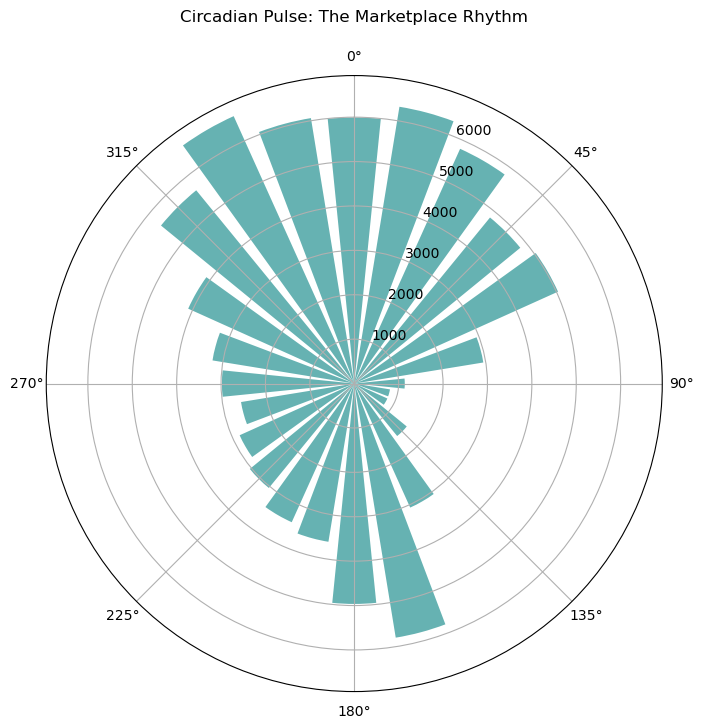

In [11]:
logins = pd.read_json('logins.json')
logins['hour'] = logins['login_time'].dt.hour
counts = logins.groupby('hour').size()

theta = np.linspace(0.0, 2 * np.pi, 24, endpoint=False)
plt.figure(figsize=(8,8))
ax = plt.subplot(111, projection='polar')
ax.bar(theta, counts, width=0.2, color='teal', alpha=0.6)
ax.set_theta_zero_location('N')
ax.set_theta_direction(-1)
ax.set_title("Circadian Pulse: The Marketplace Rhythm", pad=20)
plt.show()

## 3. Modeling with 'Smetana' Layering
Using Gradient Boosting to capture complex interactions between cultural features.

In [14]:
features = ['avg_dist', 'avg_rating_by_driver', 'pali_pali_score', 
            'dacha_factor', 'usage_entropy', 'ultimate_black_user', 'surge_pct']
X = df[features].fillna(df[features].mean())
y = df['retained']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=5)
model.fit(X_train, y_train)

print(f"Model Trained. AUC-ROC: {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]):.4f}")

Model Trained. AUC-ROC: 0.8132


## Strategic Recommendations
•	Efficiency Optimization: Launch a 'Pali-Pali' express UI for high-intent urban commuters.
•	Seasonal Loyalty: Incentivize 'Dacha' migrations with weekend bundles to secure high-margin supply.
•	Hazard Mitigation: Focus engagement campaigns on Day 45 to Day 60 to prevent the 'second-month slump'.
